In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import re
import os
import glob
import sys
from tqdm import tqdm
import datetime
import gc
import numpy as np
import tensorflow as tf

In [38]:
config = {
    'project_path': 'drive/MyDrive/author-handwriting-recog',
    'dataset': 'complete_dataset_20260122-142244.tar.gz',
    'authors_range': range(50),
    'input_shape': (60, 53, 1),
    'embedding_dim': 256,
    'epochs': 15
}

In [3]:
project_path = 'drive/MyDrive/author-handwriting-recog'

In [4]:
sys.path.insert(0, project_path)

In [5]:
sys.path

['drive/MyDrive/author-handwriting-recog',
 '/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython']

In [6]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 48.4 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=89fec82c8d089e609271bcdaeb866ae520c99a4cc725fa0f119fe48c276c3c39
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [7]:
from src.io.exceptions import DeserializationError
from src.io.logging import LoggerFactory
from src import SelectiveDataLoader
from src.io import load

In [8]:
dataset_path = f"{project_path}/data/datasets/complete_dataset_20260122-142244.tar.gz"

In [9]:
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

In [10]:
logger = LoggerFactory.get_notebook_logger("code_1", log_dir=f"./logs_{current_time}")

In [11]:
!tar -xzf {dataset_path} -C ./

In [12]:
loader = SelectiveDataLoader(
        dataset_path="./complete_dataset_20260122-142244.zarr",
        load_fn=load
        )

08:20:34 - ZarrSerializer - INFO - Initialized with blosc compression (level 5)
08:20:34 - ZarrSerializer - INFO - ======================================================================
08:20:34 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
08:20:34 - ZarrSerializer - INFO - ======================================================================
08:20:34 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
08:20:34 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
08:20:34 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
08:20:34 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
08:20:34 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
08:20:34 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
08:20:34 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
08:20:34 - ZarrSerializer - INFO - ======================

In [14]:
from src.datasets import DataInitializer, PatchNormalizer, SubsetBuilder

In [15]:
normalizer = PatchNormalizer()

In [16]:
subset_builder = SubsetBuilder(
    loader=loader,
    data_normalizer=normalizer
)

In [18]:
subset = subset_builder.build(
    authors_range=config['authors_range'],
    show_progress_bar=True,
)

08:22:33 - ZarrSerializer - INFO - ======================================================================
08:22:33 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
08:22:33 - ZarrSerializer - INFO - ======================================================================
08:22:33 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
08:22:33 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
08:22:33 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
08:22:33 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
08:22:33 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
08:22:33 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
08:22:33 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
08:22:33 - ZarrSerializer - INFO - ======================================================================
08:22:33 - ZarrSerializer - INF

Building subset dataset: 100%|██████████| 150/150 [00:17<00:00,  8.60it/s]


In [19]:
subset.keys()

dict_keys(['train', 'validation', 'test'])

In [20]:
from src.datasets import PairGenerator

In [21]:
train_gen = PairGenerator(
    data=subset['train'].data,
    authors_ids=subset['train'].authors_ids,
    valid_authors=subset['train'].valid_authors,
    batch_size=64,
    shuffle=True,
    use_augmentation=True,
    seed=42
)

In [26]:
val_gen = PairGenerator(
    data=subset['validation'].data,
    authors_ids=subset['validation'].authors_ids,
    valid_authors=subset['validation'].valid_authors,
    batch_size=32,
    use_augmentation=False,
    shuffle=False,
)

In [24]:
test_gen = PairGenerator(
    data=subset['test'].data,
    authors_ids=subset['test'].authors_ids,
    valid_authors=subset['test'].valid_authors,
    batch_size=8,
    use_augmentation=False,
    shuffle=False,
)

In [27]:
len(train_gen), len(val_gen), len(test_gen)

(2402, 780, 776)

In [28]:
logger.info(f"Train samples: {train_gen.num_patches}")
logger.info(f"Validation samples: {val_gen.num_patches}")
logger.info(f"Test samples: {test_gen.num_patches}")
logger.info(f"Ratio: {train_gen.num_patches / val_gen.num_patches:.2f}")

INFO - Train samples: 153701
INFO - Validation samples: 24954
INFO - Test samples: 6201
INFO - Ratio: 6.16


In [29]:
logger.info(f"Train augmentation: {train_gen.augmenter is not None}")
logger.info(f"Val augmentation: {val_gen.augmenter is not None}")
logger.info(f"Test augmentation: {test_gen.augmenter is not None}")

INFO - Train augmentation: True
INFO - Val augmentation: False
INFO - Test augmentation: False


In [30]:
from src.models import (
    CNNBackbone,
    CNNTransformerBackbone,
    build_siamese_model,
    build_embedding_model,
)
from src.models.training import ModelTrainer, get_default_callbacks
from src.models.evaluation import (
    ModelComparator,
    ModelEvaluator,
    plot_training_history,
    plot_comparison_metrics,
    plot_embeddings_tsne
)

In [31]:
backbone = CNNBackbone()

In [32]:
cnn_trainer = ModelTrainer(
    backbone=backbone,
    input_shape=config['input_shape'],
    embedding_dim=256,
    model_name="siamese_cnn",
    log_dir=f"./logs_{current_time}"
)

08:25:52 - siamese_cnn_trainer - INFO - Model trainer initialized: siamese_cnn
08:25:52 - siamese_cnn_trainer - INFO - Input shape: (60, 53, 1)
08:25:52 - siamese_cnn_trainer - INFO - Embedding dim: 256


In [33]:
cnn_trainer.build()
cnn_trainer.compile()

08:26:20 - siamese_cnn_trainer - INFO - Building models...
08:26:22 - siamese_cnn_trainer - INFO - Model built: siamese_model
08:26:22 - siamese_cnn_trainer - INFO - Total params: 455552
08:26:22 - siamese_cnn_trainer - INFO - Trainable params: 454592
08:26:22 - siamese_cnn_trainer - INFO - Compiling model...
08:26:22 - siamese_cnn_trainer - INFO - Model compiled
08:26:22 - siamese_cnn_trainer - INFO -   - Optimizer: Adam
08:26:22 - siamese_cnn_trainer - INFO -   - Learning rate: 0.0001
08:26:22 - siamese_cnn_trainer - INFO -   - Loss: BinaryCrossEntropyDistance
08:26:22 - siamese_cnn_trainer - INFO -   - Loss scale: 10.0


In [35]:
cnn_history = cnn_trainer.train(
    train_generator=train_gen,
    val_generator=val_gen,
    epochs=config['epochs'],
    verbose=1
)

08:27:04 - siamese_cnn_trainer - INFO - Starting training for 15 epochs...
08:27:04 - siamese_cnn_trainer - INFO -   - Train batches: 2402
08:27:04 - siamese_cnn_trainer - INFO -   - Val batches: 780
Epoch 1/15
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.7687
Epoch 1: val_loss improved from inf to 0.69025, saving model to checkpoints/siamese_cnn/best.keras
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 348s 141ms/step - loss: 0.7687 - val_loss: 0.6902 - learning_rate: 1.0000e-04
Epoch 2/15
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.6919
Epoch 2: val_loss improved from 0.69025 to 0.68713, saving model to checkpoints/siamese_cnn/best.keras
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 338s 141ms/step - loss: 0.6919 - val_loss: 0.6871 - learning_rate: 1.0000e-04
Epoch 3/15
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.6885
Epoch 3: val_loss improved from 0.68713 to 0.68366, saving model to checkpoints/siamese_cnn/best.keras
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 338s 141ms/step - loss: 0.6885 - 

KeyboardInterrupt: 

In [36]:
cnn_trainer.save(f"./models/siamese_cnn_{current_time}.keras")

09:12:42 - siamese_cnn_trainer - INFO - Model saved to models/siamese_cnn_20260128-081933.keras


In [37]:
cnn_transformer_backbone = CNNTransformerBackbone()

In [39]:
transformer_trainer = ModelTrainer(
    backbone=cnn_transformer_backbone,
    input_shape=config['input_shape'],
    embedding_dim=config['embedding_dim'],
    model_name="siamese_cnn_transformer",
    log_dir=f"./logs_{current_time}"
)

09:13:23 - siamese_cnn_transformer_trainer - INFO - Model trainer initialized: siamese_cnn_transformer
09:13:23 - siamese_cnn_transformer_trainer - INFO - Input shape: (60, 53, 1)
09:13:23 - siamese_cnn_transformer_trainer - INFO - Embedding dim: 256


In [40]:
transformer_trainer.build()
transformer_trainer.compile()

09:13:29 - siamese_cnn_transformer_trainer - INFO - Building models...
09:13:30 - siamese_cnn_transformer_trainer - INFO - Model built: siamese_model
09:13:30 - siamese_cnn_transformer_trainer - INFO - Total params: 3087232
09:13:30 - siamese_cnn_transformer_trainer - INFO - Trainable params: 3086272
09:13:30 - siamese_cnn_transformer_trainer - INFO - Compiling model...
09:13:30 - siamese_cnn_transformer_trainer - INFO - Model compiled
09:13:30 - siamese_cnn_transformer_trainer - INFO -   - Optimizer: Adam
09:13:30 - siamese_cnn_transformer_trainer - INFO -   - Learning rate: 0.0001
09:13:30 - siamese_cnn_transformer_trainer - INFO -   - Loss: BinaryCrossEntropyDistance
09:13:30 - siamese_cnn_transformer_trainer - INFO -   - Loss scale: 10.0


In [41]:
transformer_history = transformer_trainer.train(
    train_generator=train_gen,
    val_generator=val_gen,
    epochs=8,
    verbose=1
)

09:14:06 - siamese_cnn_transformer_trainer - INFO - Starting training for 8 epochs...
09:14:06 - siamese_cnn_transformer_trainer - INFO -   - Train batches: 2402
09:14:06 - siamese_cnn_transformer_trainer - INFO -   - Val batches: 780
Epoch 1/8
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.7275
Epoch 1: val_loss improved from inf to 0.68366, saving model to checkpoints/siamese_cnn_transformer/best.keras
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 454s 180ms/step - loss: 0.7275 - val_loss: 0.6837 - learning_rate: 1.0000e-04
Epoch 2/8
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 0.6875
Epoch 2: val_loss did not improve from 0.68366
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 422s 175ms/step - loss: 0.6875 - val_loss: 0.6842 - learning_rate: 1.0000e-04
Epoch 3/8
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.6857
Epoch 3: val_loss did not improve from 0.68366
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 419s 174ms/step - loss: 0.6857 - val_loss: 0.6841 - learning_rate: 1.0000e-04
Epoch 4/8
2402/2402 ━━━

In [42]:
transformer_trainer.save(f"./models/siamese_transformer_{current_time}.keras")

10:10:49 - siamese_cnn_transformer_trainer - INFO - Model saved to models/siamese_transformer_20260128-081933.keras


In [43]:
cnn_evaluator = ModelEvaluator(
    model=cnn_trainer.siamese_model,
    model_name="siamese_cnn",
    log_dir=f"./logs_{current_time}"
)
transformer_evaluator = ModelEvaluator(
    model=transformer_trainer.siamese_model,
    model_name="siamese_transformer",
    log_dir=f"./logs_{current_time}"
)

In [45]:
comparator = ModelComparator(
    evaluators_dict={
        'Siamese CNN': cnn_evaluator,
        'Siamese CNN + Transformer': transformer_evaluator
    },
    log_dir=f"./logs_{current_time}"
)

10:11:49 - model_comparator - INFO - Comparator initialized with 2 models


In [46]:
pair_results = comparator.evaluate_all(
    test_generator=test_gen,
    distance_threshold=1.0
)

10:11:54 - model_comparator - INFO - 
Evaluating: Siamese CNN
10:11:54 - siamese_cnn_evaluator - INFO - Evaluating siamese_cnn...
10:12:48 - siamese_cnn_evaluator - INFO - Evaluation completed:
10:12:48 - siamese_cnn_evaluator - INFO -   - Accuracy:  0.5000
10:12:48 - siamese_cnn_evaluator - INFO -   - AUC:       0.6836
10:12:48 - siamese_cnn_evaluator - INFO -   - Precision: 0.5000
10:12:48 - siamese_cnn_evaluator - INFO -   - Recall:    1.0000
10:12:48 - siamese_cnn_evaluator - INFO -   - F1-Score:  0.6667
10:12:48 - model_comparator - INFO - 
Evaluating: Siamese CNN + Transformer
10:12:48 - siamese_transformer_evaluator - INFO - Evaluating siamese_transformer...
10:13:46 - siamese_transformer_evaluator - INFO - Evaluation completed:
10:13:46 - siamese_transformer_evaluator - INFO -   - Accuracy:  0.5000
10:13:46 - siamese_transformer_evaluator - INFO -   - AUC:       0.5313
10:13:46 - siamese_transformer_evaluator - INFO -   - Precision: 0.5000
10:13:46 - siamese_transformer_evaluat

In [47]:
voting_results = comparator.evaluate_all_by_voting(
    test_data=subset['test'].data,
    distance_threshold=1.0,
    min_votes=3
)

10:14:05 - model_comparator - INFO - 
Evaluating: Siamese CNN
10:14:05 - siamese_cnn_evaluator - INFO - Evaluating siamese_cnn by voting...
10:14:05 - siamese_cnn_evaluator - INFO -   - Distance threshold: 1.0
10:14:05 - siamese_cnn_evaluator - INFO -   - Minimum votes: 3


KeyboardInterrupt: 

In [48]:
best_name, best_metrics = comparator.get_best_model(metric='f1')
logger.info(f"Best model: {best_name}")
logger.info(f"  F1-Score: {best_metrics['f1']:.4f}")

10:25:46 - model_comparator - INFO - Best model by f1: Siamese CNN = 0.6667
INFO - Best model: Siamese CNN
INFO -   F1-Score: 0.6667


In [40]:
results = comparator.evaluate_all(
    test_generator=test_gen,
    distance_threshold=1.0
)

15:15:14 - model_comparator - INFO - ============================================================
15:15:14 - model_comparator - INFO - EVALUATING MODELS
15:15:14 - model_comparator - INFO - ============================================================
15:15:16 - model_comparator - INFO - 
Evaluating: Siamese CNN
15:16:08 - model_comparator - INFO -   - Accuracy:  0.5000
15:16:08 - model_comparator - INFO -   - AUC:       0.6258
15:16:08 - model_comparator - INFO -   - Precision: 0.5000
15:16:08 - model_comparator - INFO -   - Recall:    1.0000
15:16:08 - model_comparator - INFO -   - F1-Score:  0.6667
15:16:08 - model_comparator - INFO - 
Evaluating: Siamese CNN + Transformer
15:17:03 - model_comparator - INFO -   - Accuracy:  0.5000
15:17:03 - model_comparator - INFO -   - AUC:       0.6348
15:17:03 - model_comparator - INFO -   - Precision: 0.5000
15:17:03 - model_comparator - INFO -   - Recall:    1.0000
15:17:03 - model_comparator - INFO -   - F1-Score:  0.6667
15:17:03 - model_comp

In [41]:
best_name, best_metrics = comparator.get_best_model(metric='f1')
logger.info(f"\nBest model: {best_name}")
logger.info(f"  F1-Score: {best_metrics['f1']:.4f}")

15:17:18 - model_comparator - INFO - Best model by f1: Siamese CNN = 0.6667
INFO - 
Best model: Siamese CNN
INFO -   F1-Score: 0.6667


In [51]:
plot_training_history(
    histories={
        'Siamese CNN': cnn_trainer.history,
        'Siamese CNN + Transformer': transformer_history
    },
    save_path=f"./results/training_curves_{current_time}.png"
)

AttributeError: 'NoneType' object has no attribute 'history'

FileNotFoundError: [Errno 2] No such file or directory: './results/comparison_metrics_20260127-143319.png'

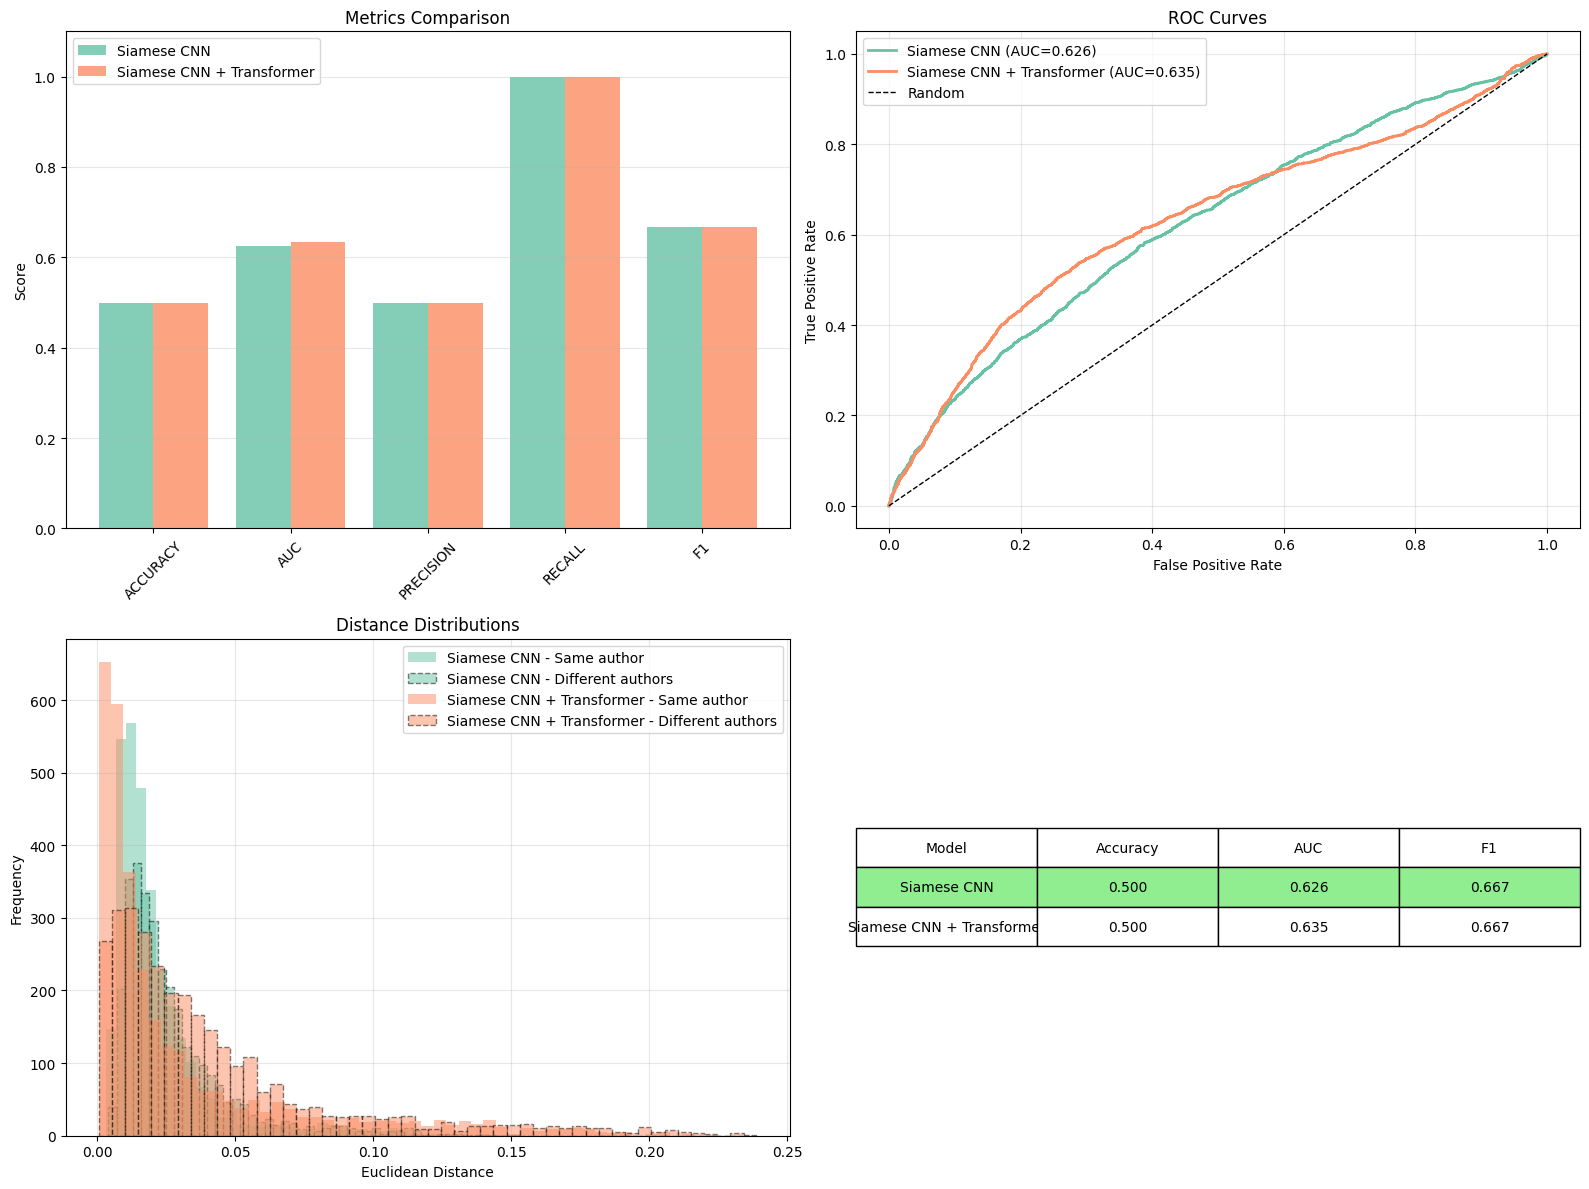

In [43]:
plot_comparison_metrics(
    results=results,
    save_path=f"./results/comparison_metrics_{current_time}.png"
)

In [52]:
def extract_embeddings(model, generator, num_samples=1000):
    embeddings = []
    labels = []

    count = 0
    for i in range(len(generator)):
        if count >= num_samples:
            break

        (img1, img2), label = generator[i]
        emb = model.predict([img1, img2], verbose=0)
        embeddings.append(emb[:, 0, :])
        labels.append(label)
        count += len(label)

    return np.concatenate(embeddings), np.concatenate(labels)

In [53]:
logger.info("Extracting embeddings for visualization...")
cnn_emb, cnn_labels = extract_embeddings(
    cnn_trainer.siamese_model,
    test_gen,
)
trans_emb, trans_labels = extract_embeddings(
    transformer_trainer.siamese_model,
    test_gen,
)

INFO - Extracting embeddings for visualization...


Figure saved to: results/embeddings_tsne_20260128-081933.png


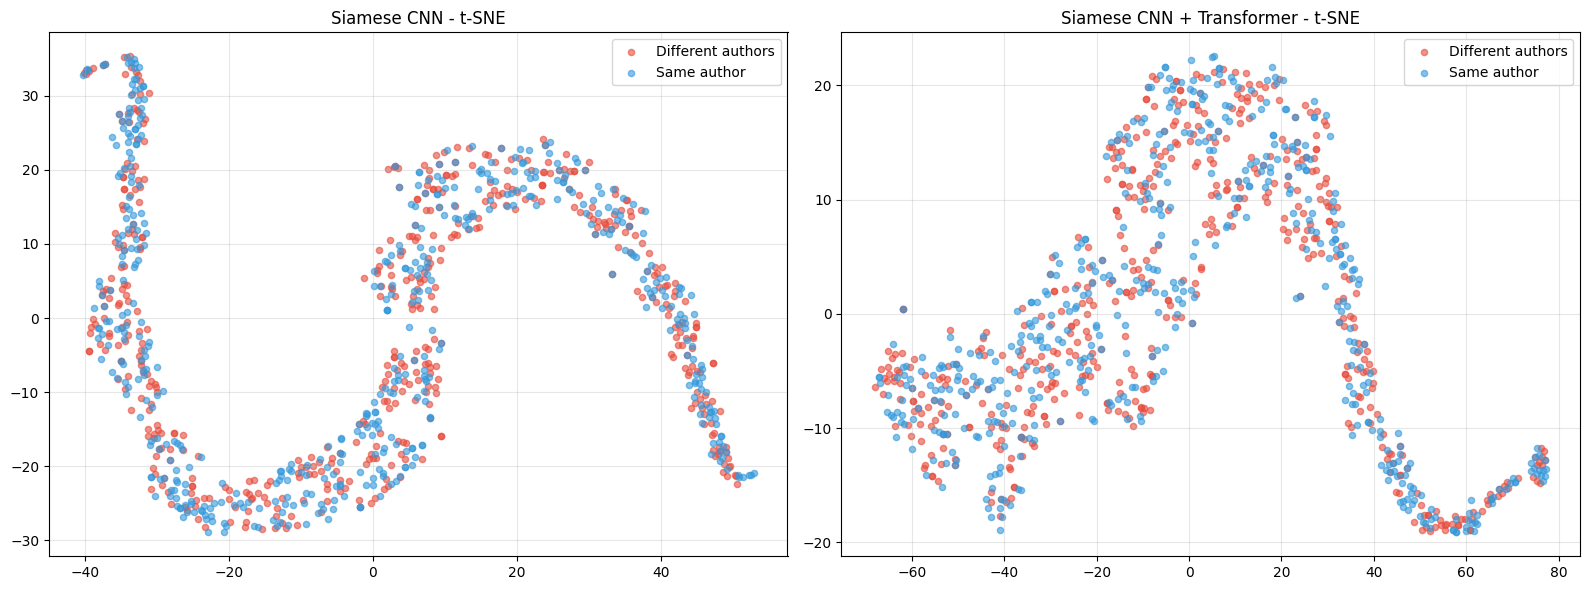

In [54]:
plot_embeddings_tsne(
    embeddings_dict={
        'Siamese CNN': cnn_emb,
        'Siamese CNN + Transformer': trans_emb
    },
    labels_dict={
        'Siamese CNN': cnn_labels,
        'Siamese CNN + Transformer': trans_labels
    },
    save_path=f"./results/embeddings_tsne_{current_time}.png"
)

In [ ]:
model = build_embedding_model(
    backbone=backbone,
    input_shape=(60, 53, 1),
    embedding_dim=256,
    name="cnn_embedding_model"
)

In [ ]:
transformer_model = build_embedding_model(
    backbone=cnn_transformer_backbone,
    input_shape=(60, 53, 1),
    embedding_dim=256,
    name="transformer_embedding_model"
)

In [ ]:
model.summary()

Model: "cnn_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 53, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 60, 53, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 53, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 60, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 26, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 30, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 15, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 7, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize (Lambda)           │ (None, 256)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,552 (1.74 MB)

 Trainable params: 454,592 (1.73 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
transformer_model.summary()

Model: "transformer_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 60, 53, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 60, 53, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 60, 53, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 60, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 30, 26, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 30, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 15, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 15, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 7, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 7, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 42, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 42, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_0           │ (None, 42, 256)        │     1,315,840 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, 42, 256)        │     1,315,840 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,087,232 (11.78 MB)

 Trainable params: 3,086,272 (11.77 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
siamese_model = build_siamese_model(
    embedding_model=model,
    input_shape=(60, 53, 1)
)

In [ ]:
transformer_siamese_model = build_siamese_model(
    embedding_model=transformer_model,
    input_shape=(60, 53, 1)
)

In [ ]:
siamese_model.summary()

Model: "siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image1 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image2 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_embedding_model │ (None, 256)       │    455,552 │ image1[0][0],     │
│ (Functional)        │                   │            │ image2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 2, 256)    │          0 │ cnn_embedding_mo… │
│                     │                   │            │ cnn_embedding_mo… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 455,552 (1.74 MB)

 Trainable params: 454,592 (1.73 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
transformer_siamese_model.summary()

Model: "siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image1 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image2 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_embedd… │ (None, 256)       │  3,087,232 │ image1[0][0],     │
│ (Functional)        │                   │            │ image2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 2, 256)    │          0 │ transformer_embe… │
│                     │                   │            │ transformer_embe… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,087,232 (11.78 MB)

 Trainable params: 3,086,272 (11.77 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
from src.models import ContrastiveLoss, BinaryCrossEntropyDistance

In [ ]:
siamese_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=ContrastiveLoss(margin=1.0)
)

In [ ]:
transformer_siamese_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=ContrastiveLoss(margin=1.0)
)

In [ ]:
history = siamese_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1
)

Epoch 1/10
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 350s 146ms/step - loss: 0.2370 - val_loss: 0.2349
Epoch 2/10
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 350s 146ms/step - loss: 0.2352 - val_loss: 0.2284
Epoch 3/10
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 341s 142ms/step - loss: 0.2346 - val_loss: 0.2310
Epoch 4/10
 330/2402 ━━━━━━━━━━━━━━━━━━━━ 4:47 139ms/step - loss: 0.2332

KeyboardInterrupt: 

In [ ]:
history_transformer = transformer_siamese_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1
)

Epoch 1/10
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 451s 178ms/step - loss: 0.2522 - val_loss: 0.2381
Epoch 2/10
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 423s 176ms/step - loss: 0.2364 - val_loss: 0.2325
Epoch 3/10
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 423s 176ms/step - loss: 0.2336 - val_loss: 0.2253
Epoch 4/10
  72/2402 ━━━━━━━━━━━━━━━━━━━━ 6:32 169ms/step - loss: 0.2291

KeyboardInterrupt: 

In [ ]:
from src.datasets import AuthorPartitionState

In [ ]:
def resize_batch(X: np.ndarray, target_size=(60, 53)) -> np.ndarray:
    return tf.image.resize(
        X,
        target_size,
        method="bilinear"
    ).numpy()

In [ ]:
X_test, y_test = subset['test'].flatten_data()

In [ ]:
X_test_resized = resize_batch(X_test)

In [ ]:
embeddings_test = model.predict(
    X_test_resized,
    batch_size=32,
    verbose=1
)

194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
embeddings_transformer_test = transformer_model.predict(
    X_test_resized,
    batch_size=32,
    verbose=1
)

194/194 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [ ]:
from itertools import combinations

def build_eval_pairs(
    embeddings: np.ndarray,
    labels: np.ndarray,
    max_pos_pairs_per_author: int = 50,
    neg_pos_ratio: float = 1.0,
    seed: int = 42
):
    rng = np.random.default_rng(seed)

    E1, E2, y = [], [], []

    unique_authors = np.unique(labels)
    if len(unique_authors) < 2:
        raise ValueError("Not enough authors to generate pairs")

    # Positive pairs
    pos_pairs = []
    for author in unique_authors:
        idx = np.where(labels == author)[0]
        if len(idx) < 2:
            continue

        pairs = list(combinations(idx, 2))
        rng.shuffle(pairs)
        pairs = pairs[:max_pos_pairs_per_author]

        for i, j in pairs:
            pos_pairs.append((i, j))

    if len(pos_pairs) == 0:
      raise ValueError("No positive pairs found")

    # Negative pairs
    num_neg = int(len(pos_pairs) * neg_pos_ratio)
    neg_pairs = []
    attempts = 0
    max_attempts = num_neg * 10

    while len(neg_pairs) < num_neg and attempts < max_attempts:
        a1, a2 = rng.choice(unique_authors, size=2, replace=False)
        i = rng.choice(np.where(labels == a1)[0])
        j = rng.choice(np.where(labels == a2)[0])

        neg_pairs.append((i, j))
        attempts += 1


    for i, j in pos_pairs:
        E1.append(embeddings[i])
        E2.append(embeddings[j])
        y.append(1)

    for i, j in neg_pairs:
        E1.append(embeddings[i])
        E2.append(embeddings[j])
        y.append(0)

    return np.array(E1), np.array(E2), np.array(y)

In [ ]:
E1, E2, y_pairs = build_eval_pairs(embeddings_test, y_test)

In [ ]:
E1, E2, y_pairs = build_eval_pairs(embeddings_transformer_test, y_test)

In [ ]:
logger.info(f"Unique labels in y_test: {np.unique(y_test)}")
logger.info(f"Positive pairs: {np.sum(y_pairs == 1)}")
logger.info(f"Negative pairs: {np.sum(y_pairs == 0)}")

INFO - Unique labels in y_test: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
INFO - Positive pairs: 2500
INFO - Negative pairs: 2500


In [ ]:
logger.info(f"Unique labels in y_test: {np.unique(y_test)}")
logger.info(f"Positive pairs: {np.sum(y_pairs == 1)}")
logger.info(f"Negative pairs: {np.sum(y_pairs == 0)}")

INFO - Unique labels in y_test: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
INFO - Positive pairs: 2500
INFO - Negative pairs: 2500


In [ ]:
distances = np.linalg.norm(E1 - E2, axis=1)

In [ ]:
distances = np.linalg.norm(E1 - E2, axis=1)

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_pairs, -distances)
roc_auc = auc(fpr, tpr)

logger.info(f"AUC: {roc_auc:.4f}")

INFO - AUC: 0.8082


In [ ]:
fnr = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
eer = fpr[eer_idx]

logger.info(f"EER: {eer:.4f}")

INFO - EER: 0.2680


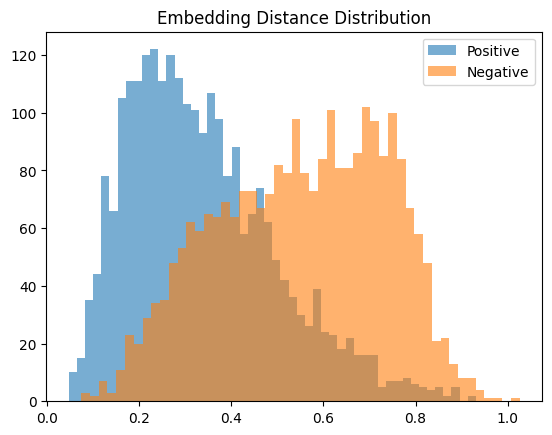

In [ ]:
import matplotlib.pyplot as plt

plt.hist(distances[y_pairs == 1], bins=50, alpha=0.6, label="Positive")
plt.hist(distances[y_pairs == 0], bins=50, alpha=0.6, label="Negative")
plt.legend()
plt.title("Embedding Distance Distribution")
plt.show()

In [ ]:
X_gallery, y_gallery = subset['test'].flatten_data()

In [ ]:
emb_gallery = mode.predict(resize_batch(X_gallery))

In [ ]:
from collections import defaultdict

gallery_by_author = defaultdict(list)
for emb, lbl in zip(emb_gallery, y_gallery):
    gallery_by_author[int(lbl)].append(emb)

gallery_by_author = {
    a: np.vstack(v) for a, v in gallery_by_author.items()
}

In [ ]:
def predict_author_from_patches(
    query_patches: np.ndarray,              # (m, H, W, C)
    gallery_by_author: dict[int, np.ndarray],
    model,
    top_q: int = 3
) -> int:
    emb_query = model.predict(
        resize_batch(query_patches),
        batch_size=32,
        verbose=0
    )

    best_author = None
    best_score = np.inf

    for author, emb_gallery in gallery_by_author.items():
        dists = (
            np.sum(emb_query**2, axis=1, keepdims=True)
            + np.sum(emb_gallery**2, axis=1)
            - 2 * emb_query @ emb_gallery.T
        )

        topq = np.partition(dists, kth=top_q-1, axis=1)[:, :top_q]
        score = float(np.mean(topq))

        if score < best_score:
            best_score = score
            best_author = author

    return best_author

In [ ]:
test_state: AuthorPartitionState = subset['test']
correct, total = 0, 0

for true_author in test_state.valid_authors:
    patches = test_state.data[true_author]

    pred = predict_author_from_patches(
        np.stack(patches, axis=0),
        gallery_by_author,
        model,
        top_q=3
    )
    correct += int(pred == true_author)
    total += 1

accuracy = correct / total
logger.info(f"Author-level accuracy: {accuracy:.4f}")